# TABR datatest event inference

Evaluate datatest 15, 17, and mixed with Top3Mean/Max at event-level and subject-level.


In [8]:
from __future__ import annotations

import gc
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from scipy.special import expit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
from bin.tabr import Model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EXP_ROOT = TABR_ROOT / 'exp' / 'tabr'
DATA_ROOT = TABR_ROOT / 'data'
FINAL_THRESHOLD = 0.5
TOP_K = 3
EVENT_METHODS = ['top3_mean', 'max']
EVAL_ROOT = ROOT / 'output/apex/datatest/model_eval'
CM_ROOT = EVAL_ROOT / 'confusion_matrices'
EVAL_ROOT.mkdir(parents=True, exist_ok=True)
(CM_ROOT / 'event_level').mkdir(parents=True, exist_ok=True)
(CM_ROOT / 'subject_level').mkdir(parents=True, exist_ok=True)
print(f'Root: {ROOT}')
print(f'Device: {device}')


Root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st
Device: cuda


In [9]:
MODEL_SPECS = [
    {
        'label': 'baseline_event_model',
        'exp_name': 'convat_apex_anxiety',
        'mode': 'baseline',
    },
    {
        'label': 'qholdout_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qholdout_q123_q4_q5',
        'mode': 'qholdout',
    },
    {
        'label': 'qwalk_q12_q3_q4',
        'exp_name': 'convat_apex_anxiety_qwalk_q12_q3_q4',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qwalk_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qwalk_q123_q4_q5',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qholdout_q123_q4_q5_alis',
        'exp_name': 'convat_apex_anxiety_qholdout_q123_q4_q5_alis',
        'mode': 'qholdout',
    },
    {
        'label': 'qwalk_q12_q3_q4',
        'exp_name': 'convat_apex_anxiety_qwalk_q12_q3_q4_alis',
        'mode': 'qwalkforward',
    },
    {
        'label': 'qwalk_q123_q4_q5',
        'exp_name': 'convat_apex_anxiety_qwalk_q123_q4_q5_alis',
        'mode': 'qwalkforward',
    },
]
model_specs_df = pd.DataFrame(MODEL_SPECS)
display(model_specs_df)


,label,exp_name,mode
0,baseline_event_model,convat_apex_anxiety,baseline
1,qholdout_q123_q4_q5,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout
2,qwalk_q12_q3_q4,convat_apex_anxiety_qwalk_q12_q3_q4,qwalkforward
3,qwalk_q123_q4_q5,convat_apex_anxiety_qwalk_q123_q4_q5,qwalkforward
4,qholdout_q123_q4_q5_alis,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout
5,qwalk_q12_q3_q4,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalkforward
6,qwalk_q123_q4_q5,convat_apex_anxiety_qwalk_q123_q4_q5_alis,qwalkforward


In [10]:
FEATURE_PATHS = {
    '15_only': [ROOT / 'output/apex/datatest/features/15_04_2026/poc_abs_test.xlsx'],
    '17_only': [ROOT / 'output/apex/datatest/features/17_04_2026/poc_abs_test.xlsx'],
    '15_17_mixed': [
        ROOT / 'output/apex/datatest/features/15_04_2026/poc_abs_test.xlsx',
        ROOT / 'output/apex/datatest/features/17_04_2026/poc_abs_test.xlsx',
    ],
}

META_COLS = {
    'date', 'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'score', 'annotation_sheet',
}

def label_to_int(label: str) -> int:
    return 1 if str(label) in {'anxiety_tinggi', 'anxiety', '1', 'tinggi'} else 0


def load_scenario_features(paths: list[Path]) -> pd.DataFrame:
    dfs = []
    for path in paths:
        if not path.exists():
            raise FileNotFoundError(f'Feature file not found: {path}')
        df = pd.read_excel(path)
        if 'date' not in df.columns:
            df['date'] = path.parent.name
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    out['true_label'] = out['label'].map(label_to_int).astype(int)
    out['event_key'] = (
        out['date'].astype(str) + '|' + out['participant_raw'].astype(str) + '|' + out['question'].astype(str) + '|' +
        out['sample'].astype(str) + '|' + out['event_clip'].astype(str) + '|' + out['event_no'].astype(str)
    )
    out['subject_key'] = out['date'].astype(str) + '|' + out['participant_raw'].astype(str)
    return out

scenario_frames = {}
for scenario, paths in FEATURE_PATHS.items():
    df = load_scenario_features(paths)
    scenario_frames[scenario] = df
    print(scenario, df.shape, 'events=', df['event_key'].nunique(), 'subjects=', df['subject_key'].nunique(), 'labels=', df['label'].value_counts().to_dict())


15_only (12072, 627) events= 1000 subjects= 51 labels= {'anxiety_tinggi': 8543, 'anxiety_rendah': 3529}
17_only (9379, 627) events= 870 subjects= 47 labels= {'anxiety_tinggi': 5967, 'anxiety_rendah': 3412}
15_17_mixed (21451, 627) events= 1870 subjects= 98 labels= {'anxiety_tinggi': 14510, 'anxiety_rendah': 6941}


/tmp/ipykernel_911222/1103901541.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out['true_label'] = out['label'].map(label_to_int).astype(int)
/tmp/ipykernel_911222/1103901541.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out['event_key'] = (
/tmp/ipykernel_911222/1103901541.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmente

In [11]:
def load_best_seed_report(exp_name: str) -> tuple[int, dict, Path]:
    eval_dir = EXP_ROOT / exp_name / '0-evaluation'
    rows = []
    for run_dir in sorted([x for x in eval_dir.iterdir() if x.is_dir() and x.name.isdigit()]):
        report_path = run_dir / 'report.json'
        if not report_path.exists():
            continue
        report = json.loads(report_path.read_text())
        rows.append((int(run_dir.name), report, run_dir))
    if not rows:
        raise FileNotFoundError(f'No report.json found for {exp_name}')
    return max(rows, key=lambda x: x[1]['metrics']['val']['score'])


def load_run_config(exp_name: str, best_seed: int, report: dict) -> dict:
    seed_toml = EXP_ROOT / exp_name / f'{best_seed}.toml'
    if seed_toml.exists():
        return lib.load_config(seed_toml)
    if 'config' in report:
        return report['config']
    tuning_toml = EXP_ROOT / exp_name / '0-tuning.toml'
    if tuning_toml.exists():
        return lib.load_config(tuning_toml)
    raise FileNotFoundError(f'No config found for {exp_name} seed {best_seed}')


def resolve_data_dir(data_path: str) -> Path:
    if data_path.startswith(':data/'):
        return DATA_ROOT / data_path.removeprefix(':data/')
    return Path(data_path)


def load_model_bundle(exp_name: str) -> dict:
    best_seed, report, best_run_dir = load_best_seed_report(exp_name)
    cfg = load_run_config(exp_name, best_seed, report)
    data_dir = resolve_data_dir(cfg['data']['path'])
    feature_cols = json.loads((data_dir / 'feature_cols.json').read_text())
    dataset = lib.build_dataset(**cfg['data']).to_torch(device)
    model = Model(
        n_num_features=dataset.n_num_features,
        n_bin_features=dataset.n_bin_features,
        cat_cardinalities=dataset.cat_cardinalities(),
        n_classes=dataset.n_classes(),
        **cfg['model'],
    ).to(device)
    checkpoint = lib.load_checkpoint(best_run_dir)
    model.load_state_dict(checkpoint['model'])
    model.eval()
    candidate_x = {key[2:]: dataset.data[key]['train'] for key in dataset.data if key.startswith('X_')}
    candidate_y = dataset.Y['train']
    return {
        'model': model,
        'dataset': dataset,
        'candidate_x': candidate_x,
        'candidate_y': candidate_y,
        'feature_cols': feature_cols,
        'context_size': cfg['context_size'],
        'best_seed': best_seed,
        'data_path': cfg['data']['path'],
    }


def release_model_bundle(bundle: dict) -> None:
    del bundle
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [12]:
@torch.inference_mode()
def predict_frame_probs(bundle: dict, df: pd.DataFrame, batch_size: int = 512) -> np.ndarray:
    feature_cols = bundle['feature_cols']
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise KeyError(f'Missing feature cols: {missing[:20]}')
    x_np = df[feature_cols].to_numpy(dtype=np.float32)
    probs = []
    for start in range(0, len(x_np), batch_size):
        xb = torch.as_tensor(x_np[start:start + batch_size], device=device)
        for i in range(xb.shape[0]):
            x = {'num': xb[i:i+1]}
            logit = bundle['model'](
                x_=x,
                y=None,
                candidate_x_=bundle['candidate_x'],
                candidate_y=bundle['candidate_y'],
                context_size=bundle['context_size'],
                is_train=False,
            ).squeeze(-1).item()
            probs.append(float(expit(logit)))
    return np.asarray(probs, dtype=float)


def aggregate_probs(values, method: str, top_k: int = TOP_K) -> float:
    arr = np.asarray(list(values), dtype=float)
    if len(arr) == 0:
        return np.nan
    if method == 'max':
        return float(np.max(arr))
    if method == 'top3_mean':
        k = min(top_k, len(arr))
        return float(np.mean(np.sort(arr)[-k:]))
    raise ValueError(f'Unknown aggregation method: {method}')


In [13]:
def make_event_predictions(frame_df: pd.DataFrame, method: str) -> pd.DataFrame:
    rows = []
    group_cols = ['event_key']
    meta_cols = ['date', 'participant_raw', 'participant', 'subject_key', 'label', 'true_label', 'question', 'sample', 'event_clip', 'event_no']
    for event_key, g in frame_df.groupby(group_cols, sort=False):
        first = g.iloc[0]
        prob = aggregate_probs(g['prob_anxiety_tinggi'], method)
        row = {col: first[col] for col in meta_cols if col in g.columns}
        row.update({
            'event_key': event_key if isinstance(event_key, str) else event_key[0],
            'aggregation': method,
            'agg_prob_anxiety_tinggi': prob,
            'pred_label': int(prob >= FINAL_THRESHOLD),
            'n_frames': len(g),
        })
        rows.append(row)
    return pd.DataFrame(rows)


def make_subject_predictions(event_df: pd.DataFrame, method: str) -> pd.DataFrame:
    rows = []
    meta_cols = ['date', 'participant_raw', 'participant', 'subject_key', 'label', 'true_label']
    for subject_key, g in event_df.groupby('subject_key', sort=False):
        first = g.iloc[0]
        prob = aggregate_probs(g['agg_prob_anxiety_tinggi'], method)
        row = {col: first[col] for col in meta_cols if col in g.columns}
        row.update({
            'subject_key': subject_key,
            'aggregation': method,
            'agg_prob_anxiety_tinggi': prob,
            'pred_label': int(prob >= FINAL_THRESHOLD),
            'n_events': len(g),
        })
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_predictions(df: pd.DataFrame, level: str, scenario: str, spec: dict, method: str) -> dict:
    y_true = df['true_label'].astype(int).to_numpy()
    y_pred = df['pred_label'].astype(int).to_numpy()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_true, y_pred, labels=[0, 1], target_names=['anxiety_rendah', 'anxiety_tinggi'], output_dict=True, zero_division=0)
    return {
        'level': level,
        'scenario': scenario,
        'exp_name': spec['exp_name'],
        'label': spec['label'],
        'mode': spec['mode'],
        'aggregation': method,
        'n': len(df),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'rendah_precision': report['anxiety_rendah']['precision'],
        'rendah_recall': report['anxiety_rendah']['recall'],
        'rendah_f1': report['anxiety_rendah']['f1-score'],
        'tinggi_precision': report['anxiety_tinggi']['precision'],
        'tinggi_recall': report['anxiety_tinggi']['recall'],
        'tinggi_f1': report['anxiety_tinggi']['f1-score'],
        'macro_f1': report['macro avg']['f1-score'],
    }


def safe_name(value: str) -> str:
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value))


def plot_confusion(df: pd.DataFrame, level: str, scenario: str, spec: dict, method: str) -> Path:
    y_true = df['true_label'].astype(int).to_numpy()
    y_pred = df['pred_label'].astype(int).to_numpy()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    out_dir = CM_ROOT / level
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"{safe_name(scenario)}__{safe_name(spec['label'])}__{safe_name(spec['exp_name'])}__{method}.png"
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['rendah', 'tinggi'], yticklabels=['rendah', 'tinggi'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f"{level} | {scenario}\\n{spec['label']} | {method}")
    plt.tight_layout()
    fig.savefig(path, dpi=160)
    plt.show()
    plt.close(fig)
    return path




## Model: `convat_apex_anxiety`

2026-05-02 15:05:53.907 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 11 features= 392 data_path= :data/convat_apex_anxiety


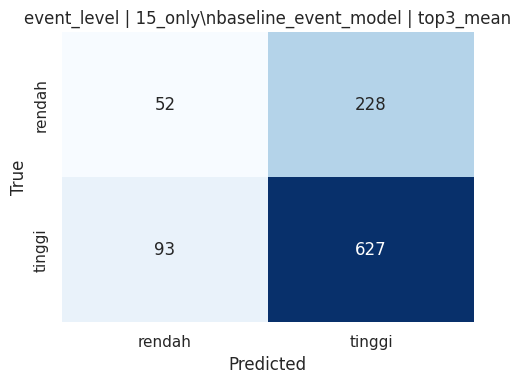

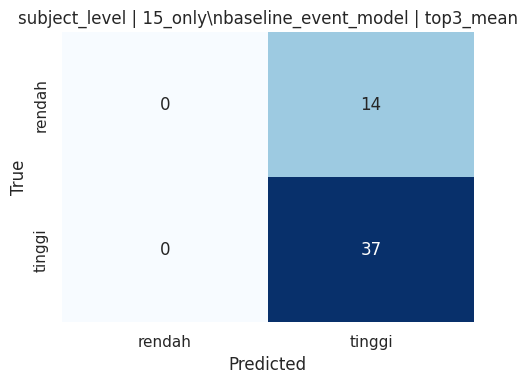

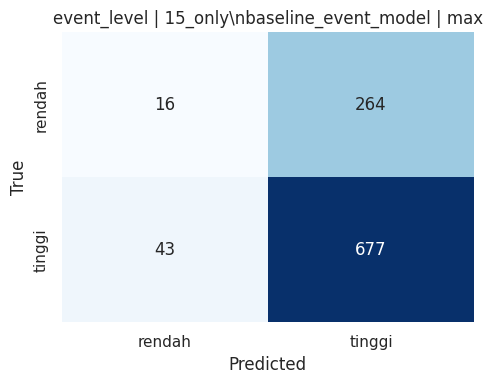

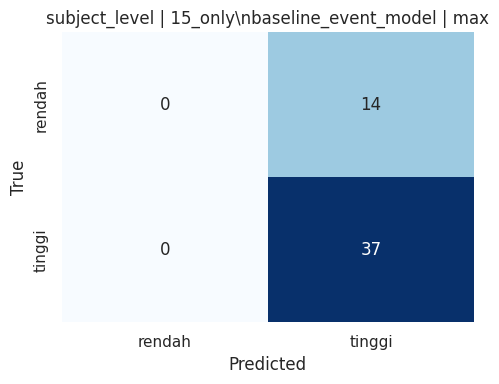

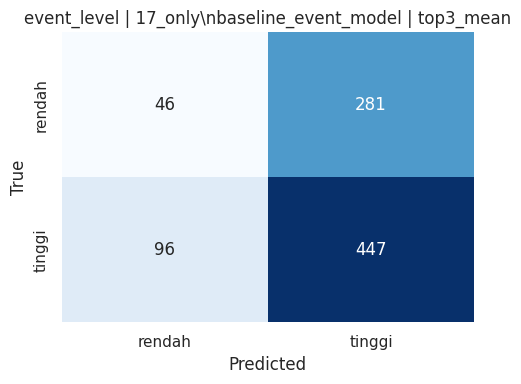

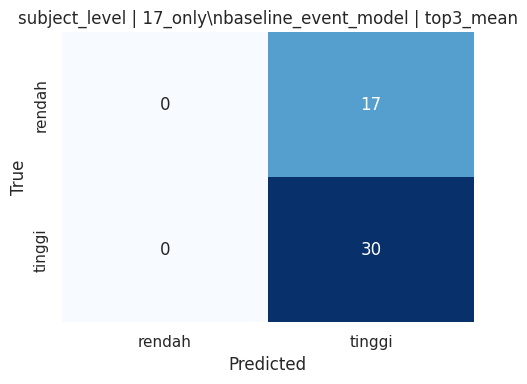

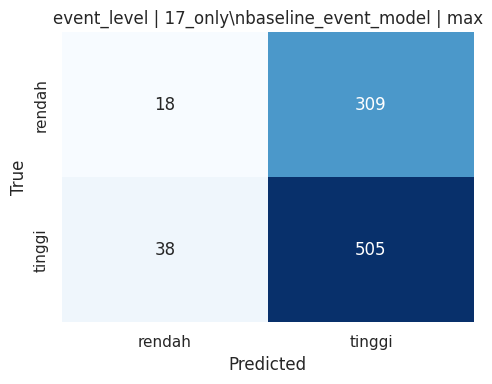

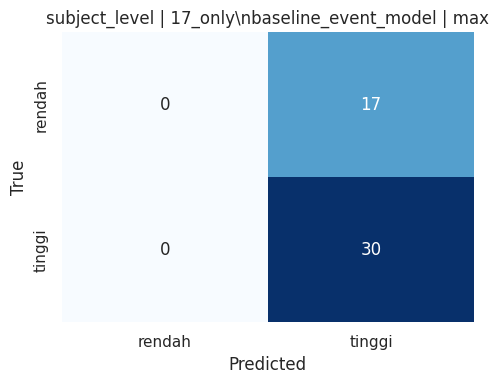

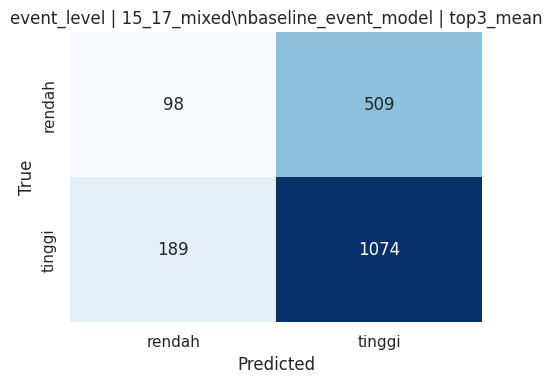

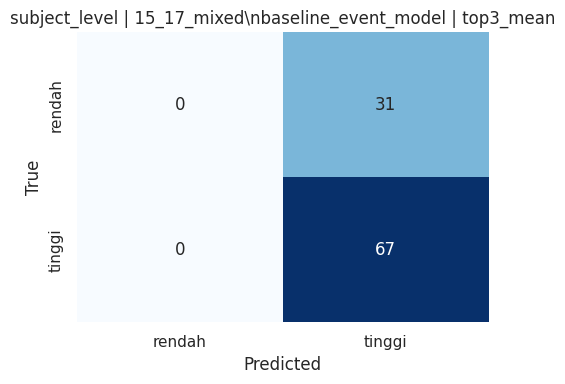

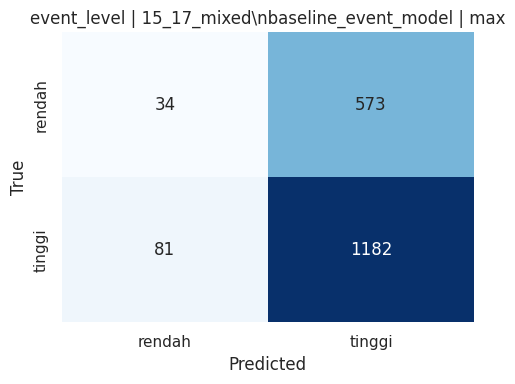

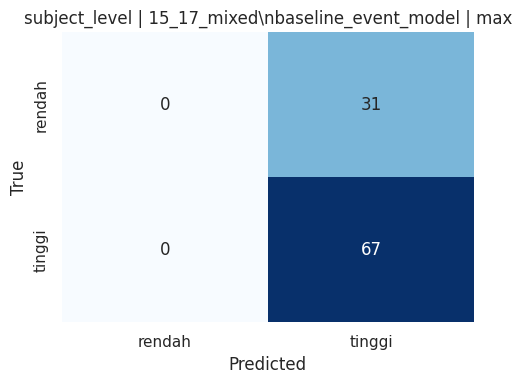

## Model: `convat_apex_anxiety_qholdout_q123_q4_q5`

2026-05-02 15:09:03.263 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qholdout_q123_q4_q5__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 13 features= 392 data_path= :data/convat_apex_anxiety_qholdout_q123_q4_q5


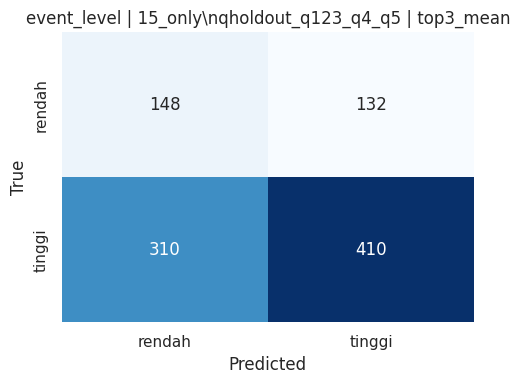

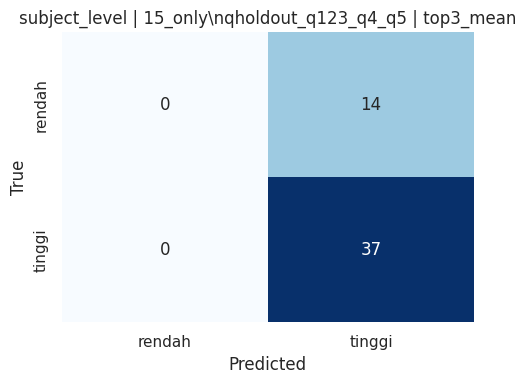

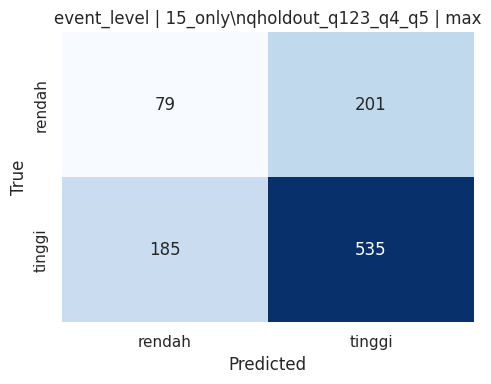

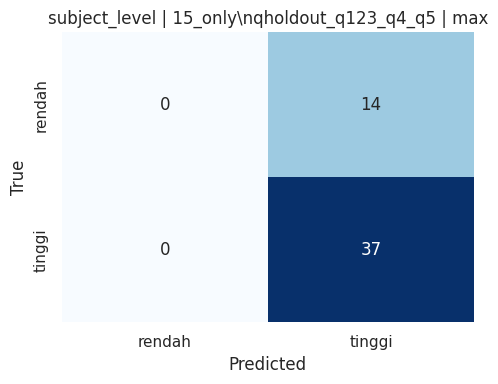

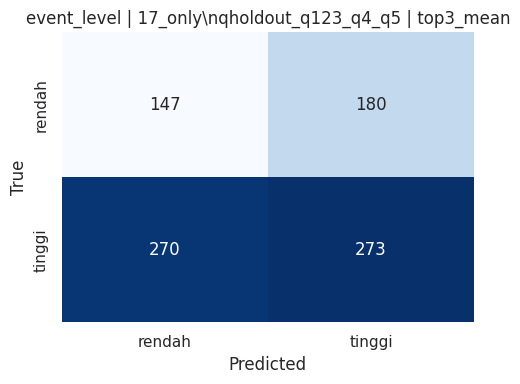

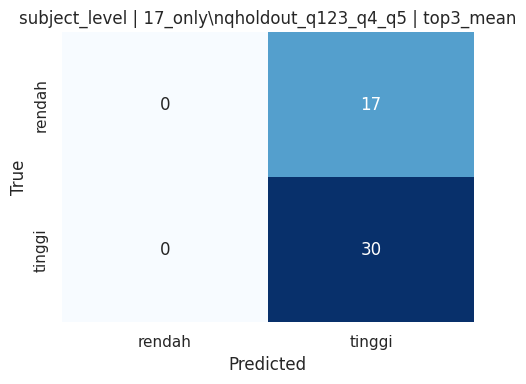

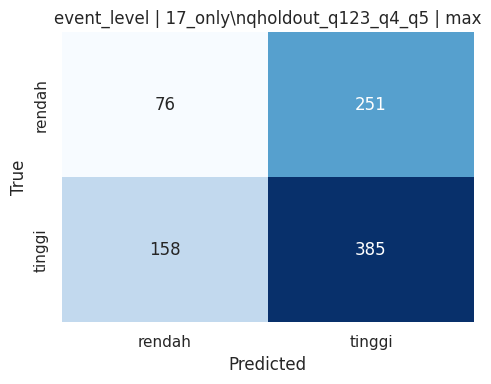

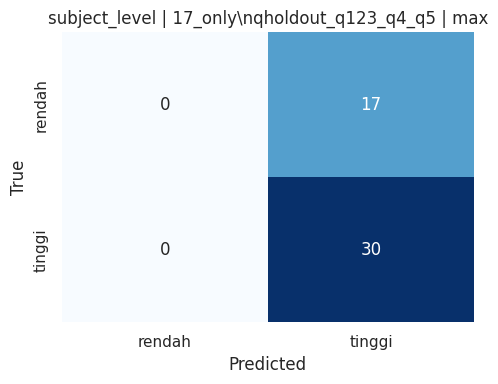

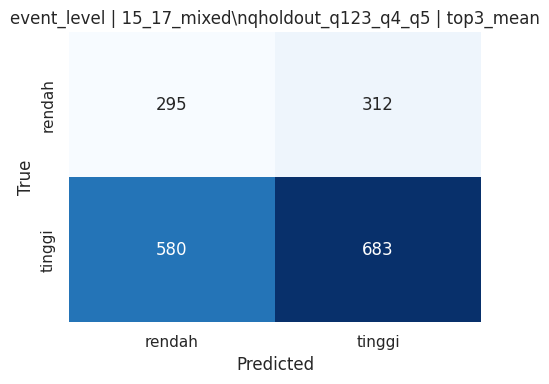

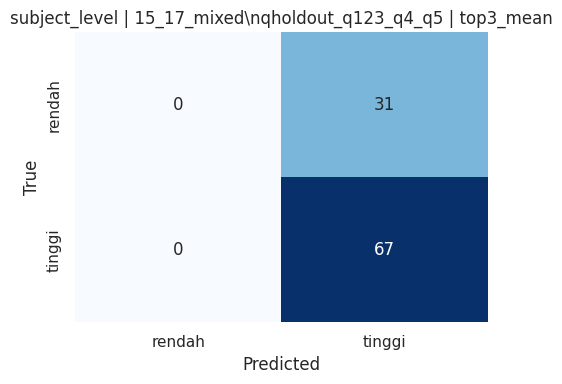

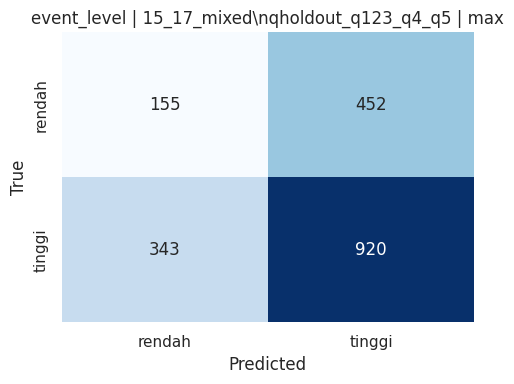

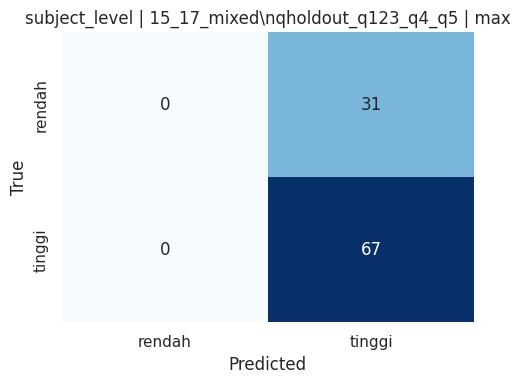

## Model: `convat_apex_anxiety_qwalk_q12_q3_q4`

2026-05-02 15:13:44.771 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q12_q3_q4__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 4 features= 392 data_path= :data/convat_apex_anxiety_qwalk_q12_q3_q4


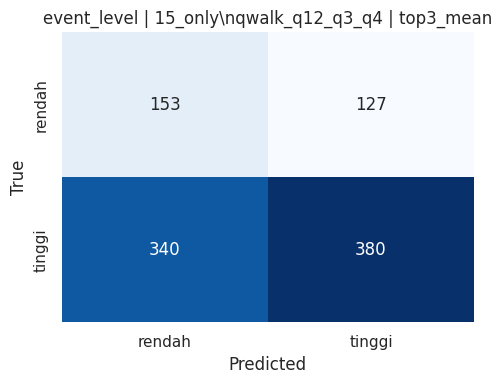

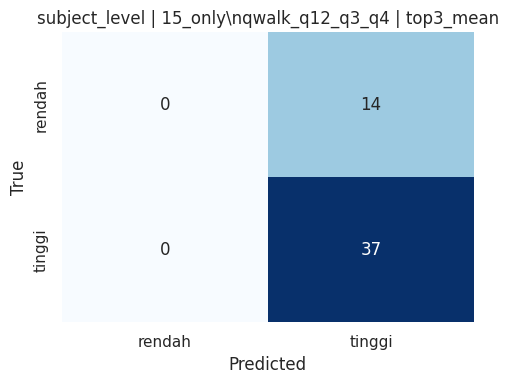

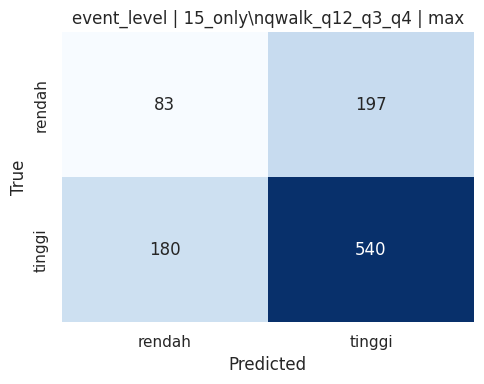

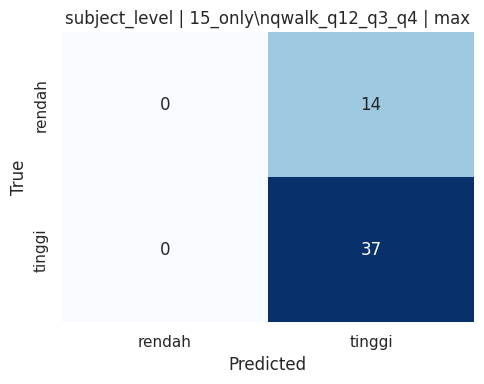

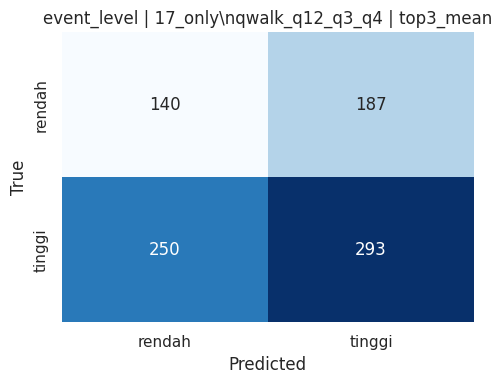

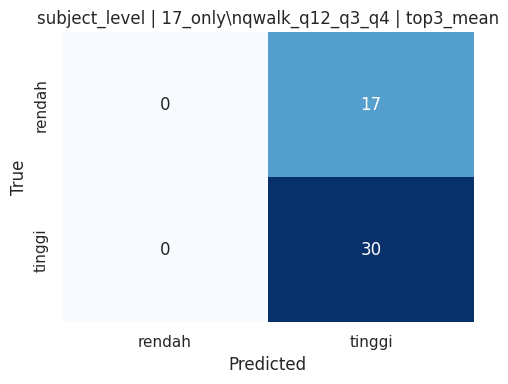

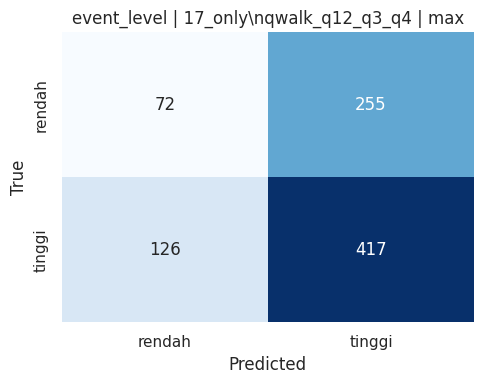

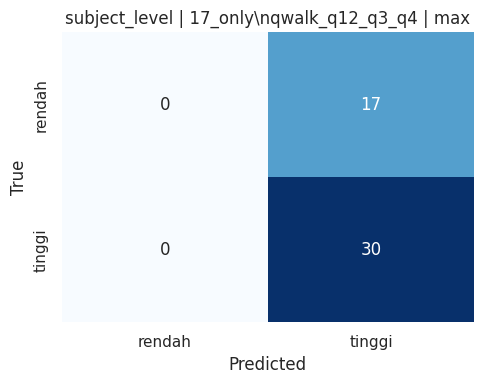

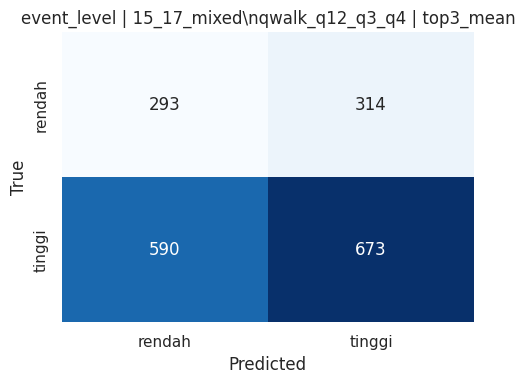

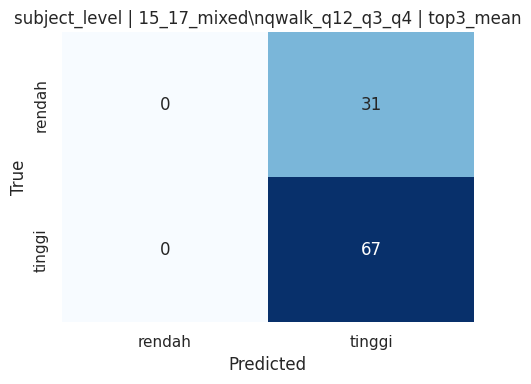

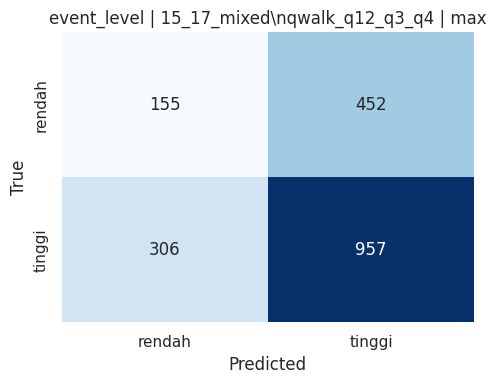

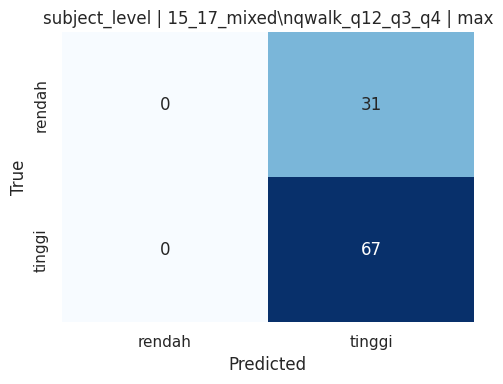

## Model: `convat_apex_anxiety_qwalk_q123_q4_q5`

2026-05-02 15:17:04.102 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q123_q4_q5__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 5 features= 392 data_path= :data/convat_apex_anxiety_qwalk_q123_q4_q5


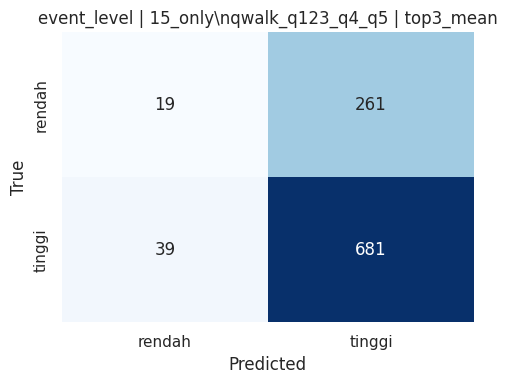

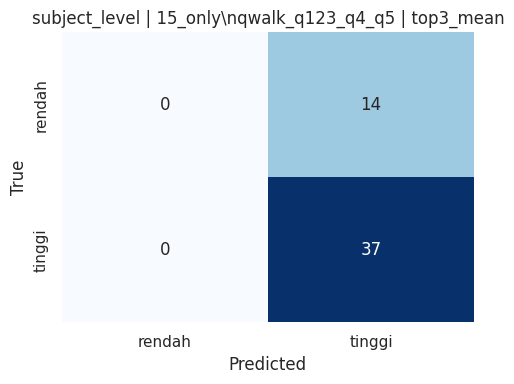

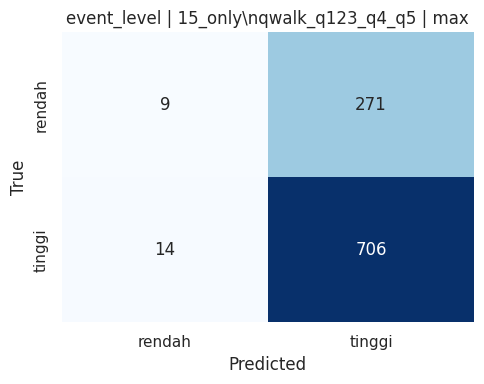

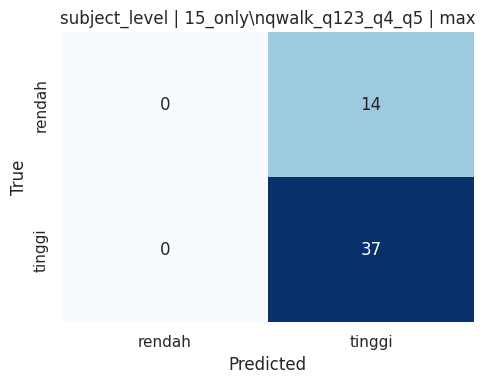

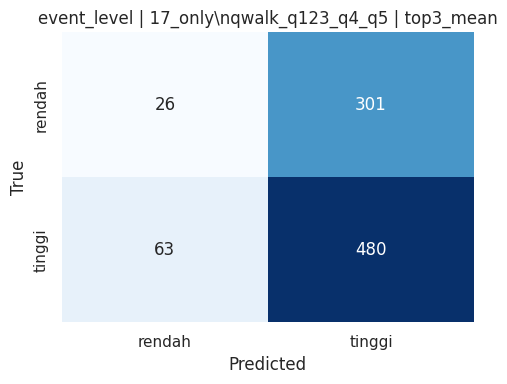

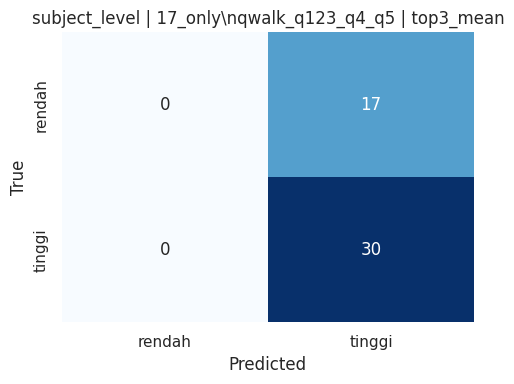

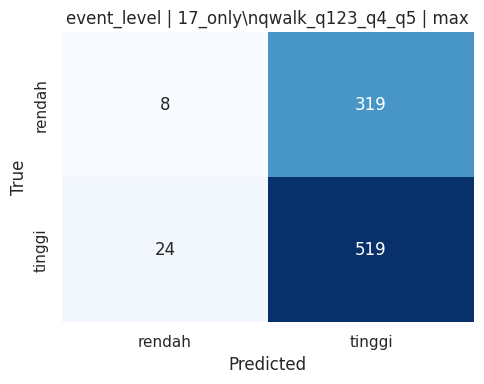

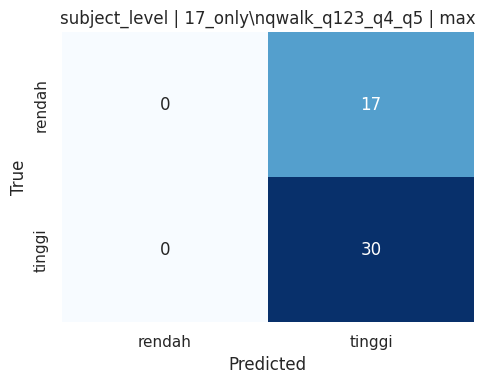

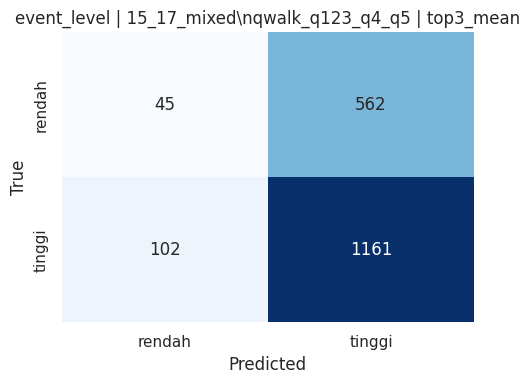

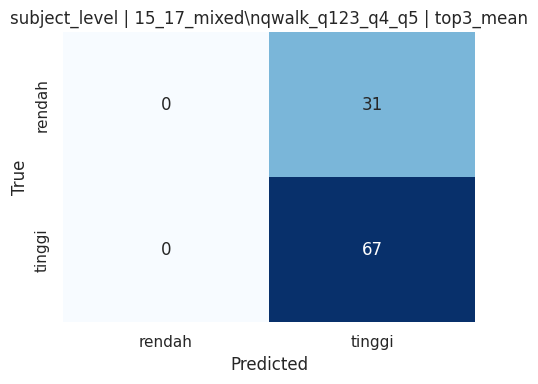

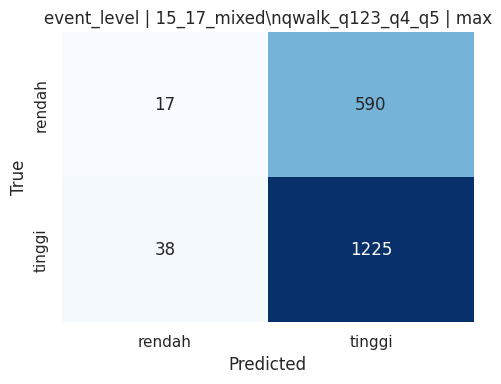

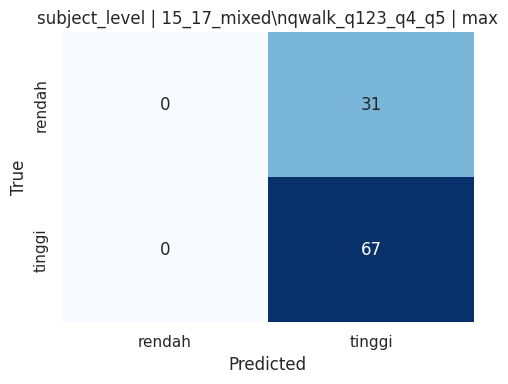

## Model: `convat_apex_anxiety_qholdout_q123_q4_q5_alis`

2026-05-02 15:20:24.803 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qholdout_q123_q4_q5_alis__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 11 features= 608 data_path= :data/convat_apex_anxiety_qholdout_q123_q4_q5_alis


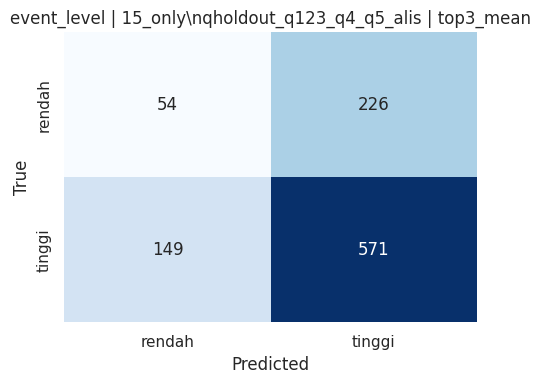

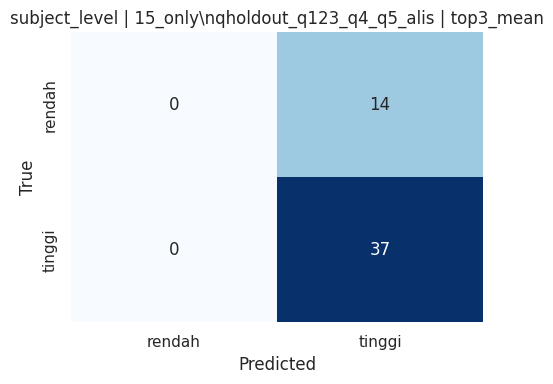

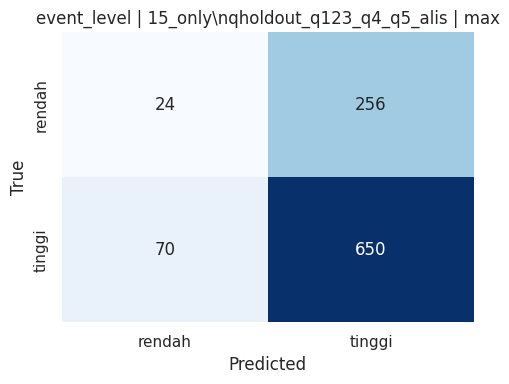

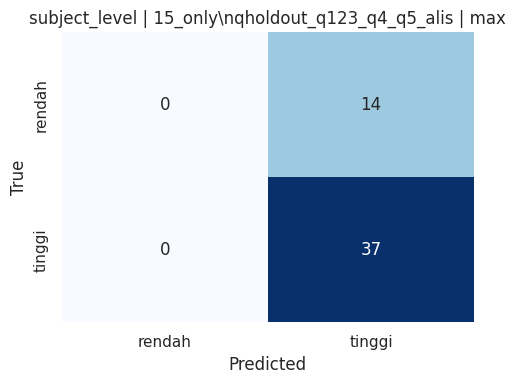

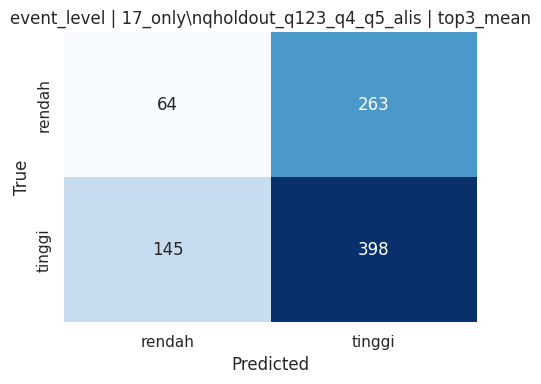

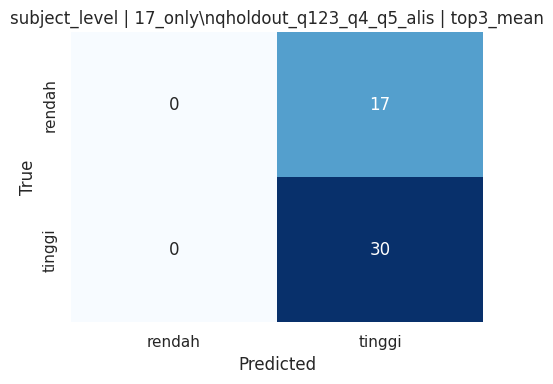

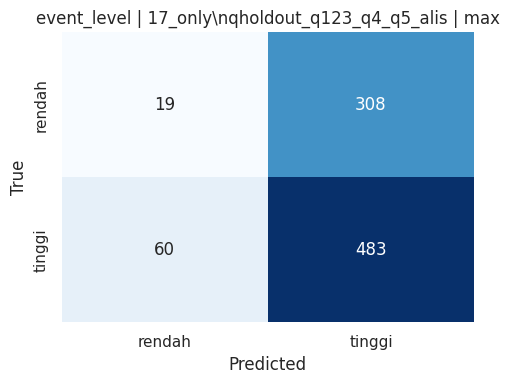

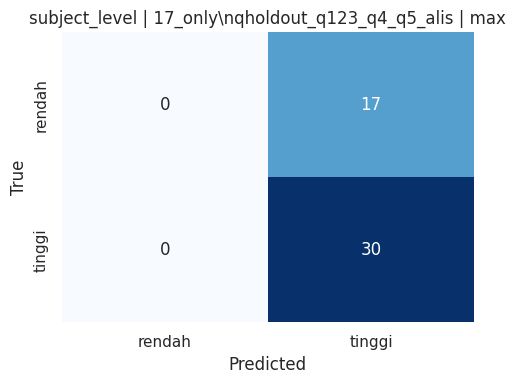

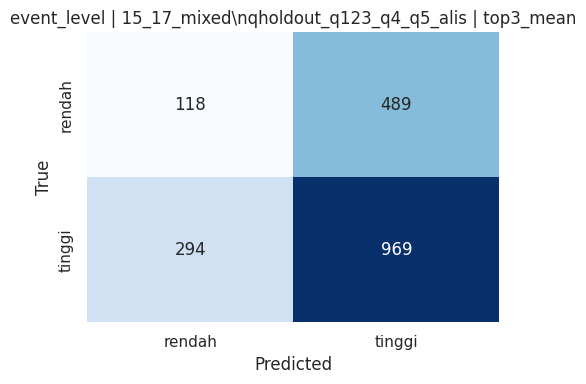

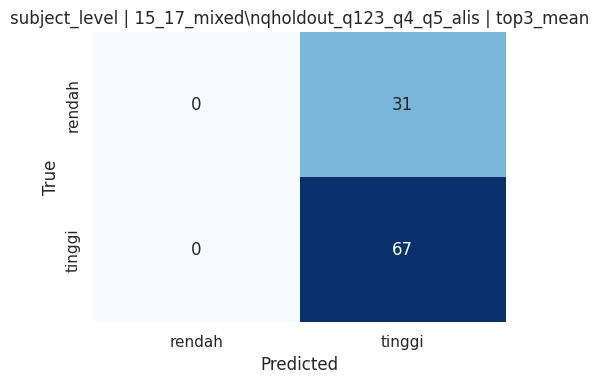

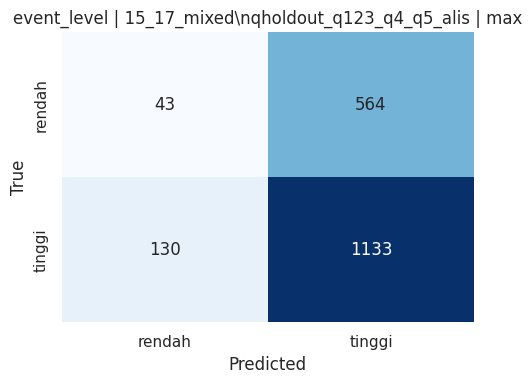

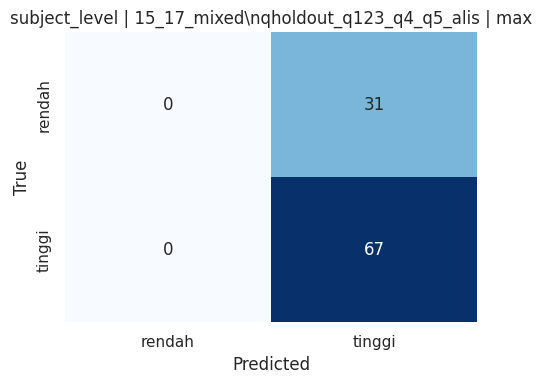

## Model: `convat_apex_anxiety_qwalk_q12_q3_q4_alis`

2026-05-02 15:27:26.165 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q12_q3_q4_alis__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 8 features= 608 data_path= :data/convat_apex_anxiety_qwalk_q12_q3_q4_alis


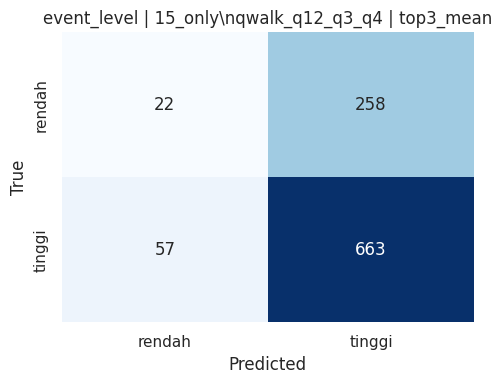

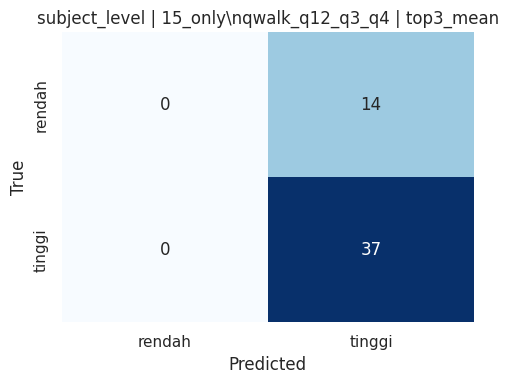

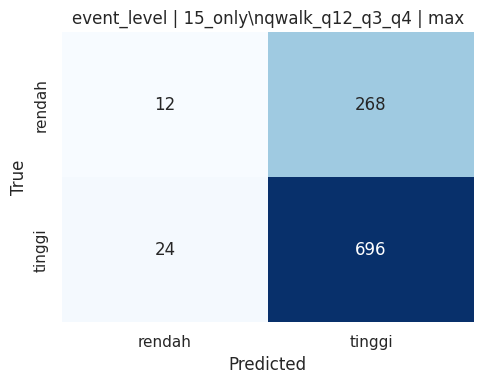

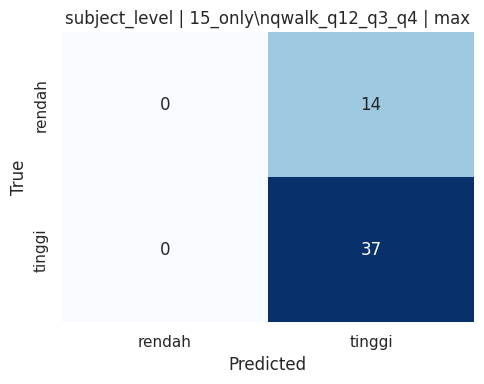

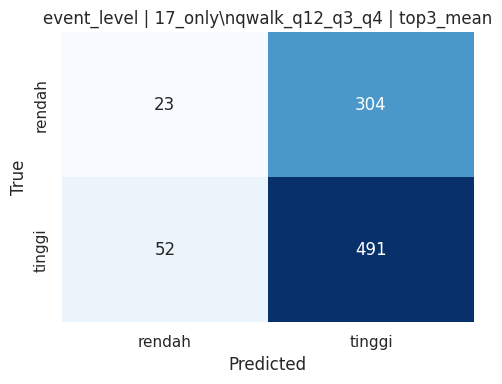

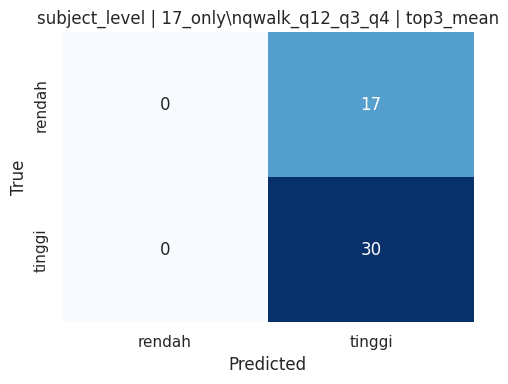

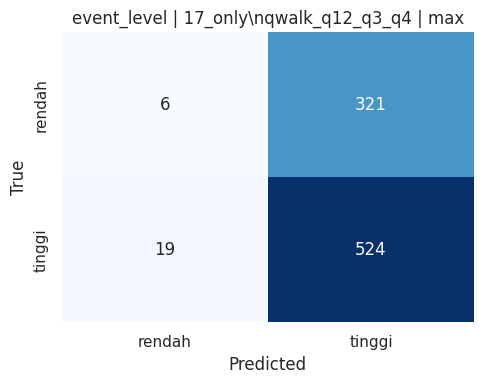

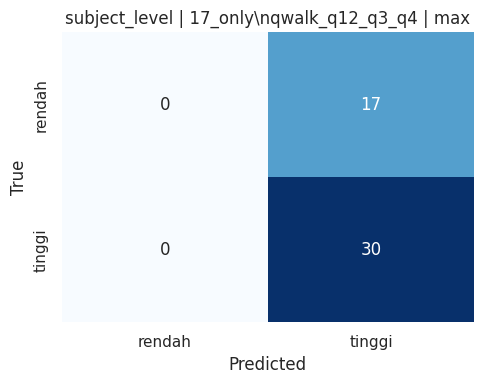

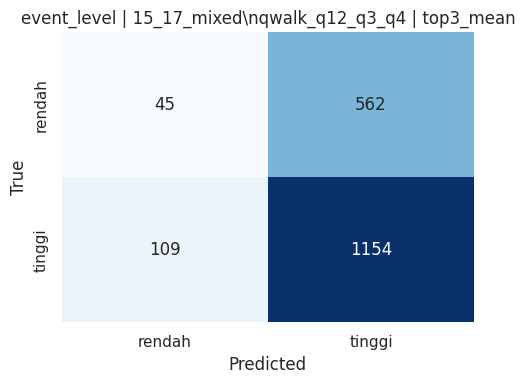

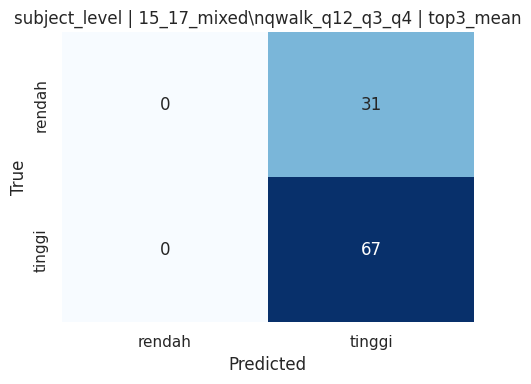

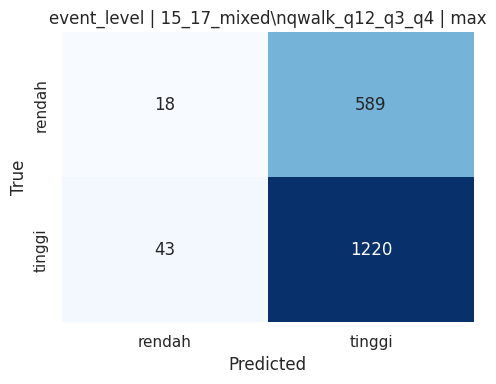

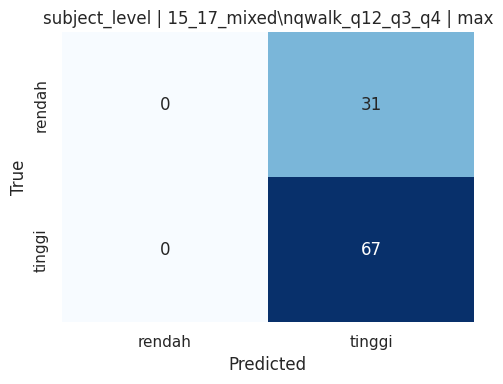

## Model: `convat_apex_anxiety_qwalk_q123_q4_q5_alis`

2026-05-02 15:30:38.316 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety_qwalk_q123_q4_q5_alis__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


best_seed= 11 features= 608 data_path= :data/convat_apex_anxiety_qwalk_q123_q4_q5_alis


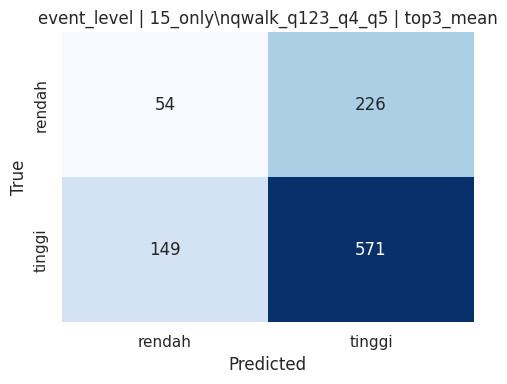

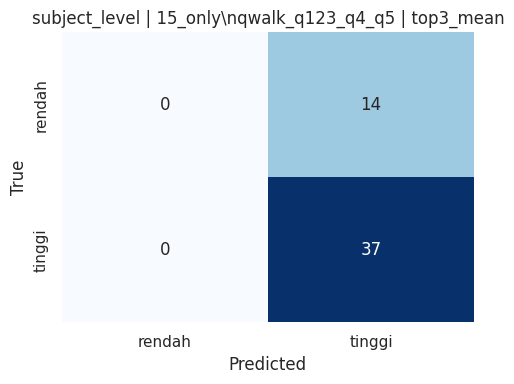

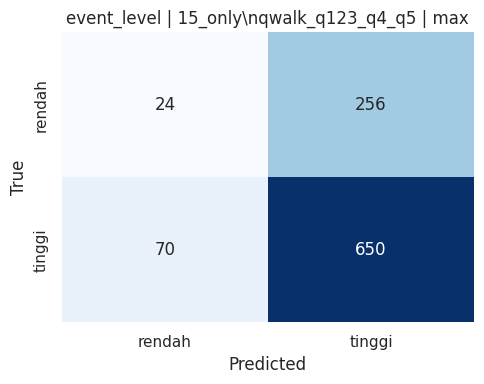

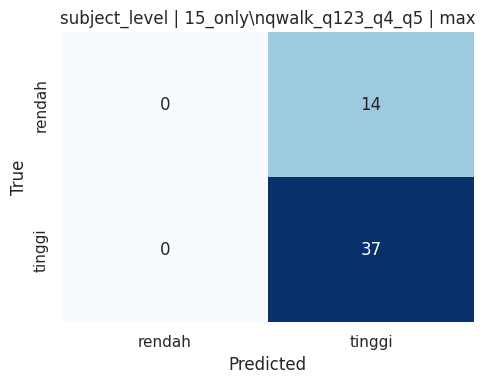

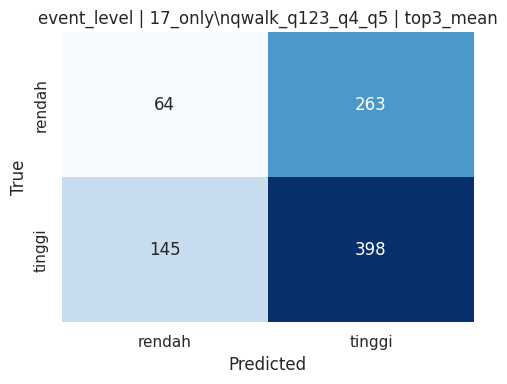

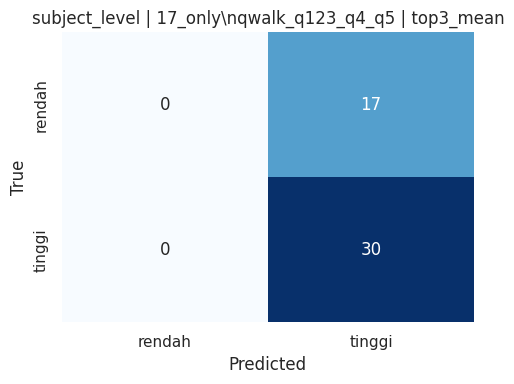

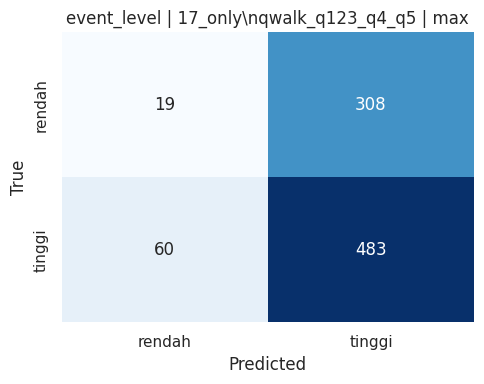

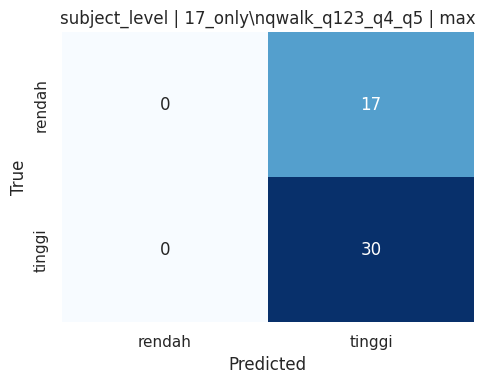

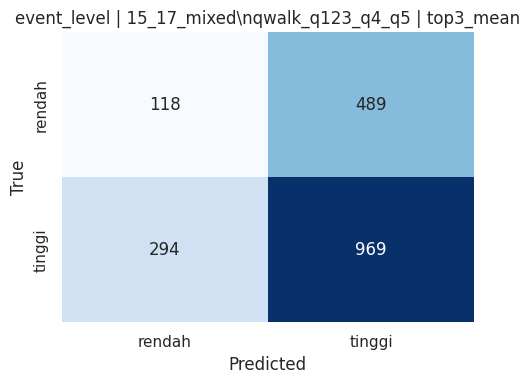

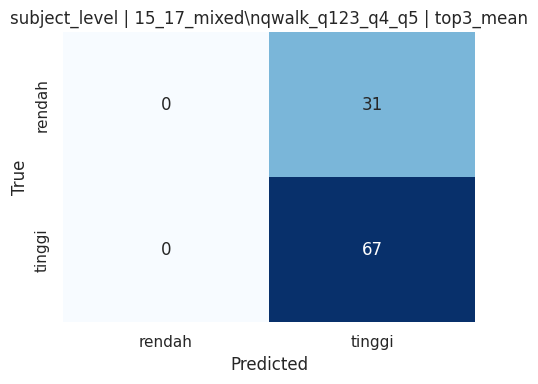

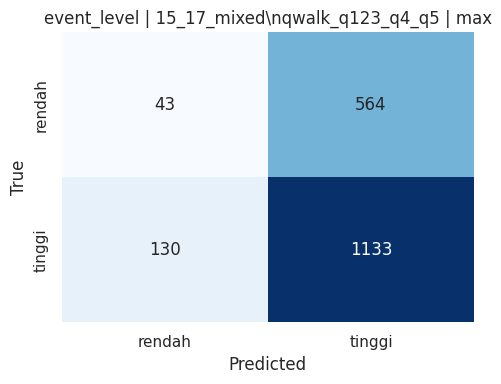

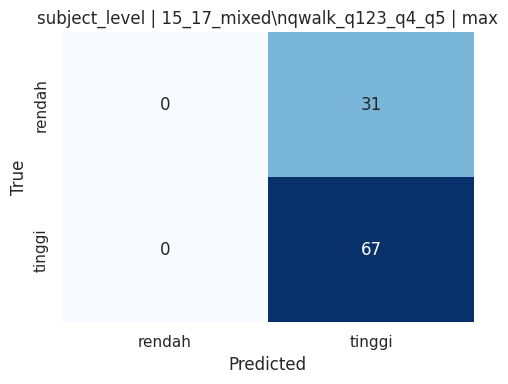

## Event-level summary

,level,scenario,exp_name,label,mode,aggregation,n,tn,fp,fn,tp,accuracy,balanced_accuracy,rendah_precision,rendah_recall,rendah_f1,tinggi_precision,tinggi_recall,tinggi_f1,macro_f1
0,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,max,1870,17,590,38,1225,0.664171,0.498960,0.309091,0.028007,0.051360,0.674931,0.969913,0.795971,0.423665
1,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalk_q12_q3_q4,qwalkforward,max,1870,18,589,43,1220,0.662032,0.497804,0.295082,0.029654,0.053892,0.674406,0.965954,0.794271,0.424082
2,event_level,15_17_mixed,convat_apex_anxiety,baseline_event_model,baseline,max,1870,34,573,81,1182,0.650267,0.495940,0.295652,0.056013,0.094183,0.673504,0.935867,0.783300,0.438742
3,event_level,15_17_mixed,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout_q123_q4_q5_alis,qholdout,max,1870,43,564,130,1133,0.628877,0.483955,0.248555,0.070840,0.110256,0.667649,0.897070,0.765541,0.437898
4,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q123_q4_q5_alis,qwalk_q123_q4_q5,qwalkforward,max,1870,43,564,130,1133,0.628877,0.483955,0.248555,0.070840,0.110256,0.667649,0.897070,0.765541,0.437898
5,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4,qwalk_q12_q3_q4,qwalkforward,max,1870,155,452,306,957,0.594652,0.506537,0.336226,0.255354,0.290262,0.679205,0.757720,0.716317,0.503290
6,event_level,15_17_mixed,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,qholdout,max,1870,155,452,343,920,0.574866,0.491889,0.311245,0.255354,0.280543,0.670554,0.728424,0.698292,0.489418
7,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,top3_mean,1870,45,562,102,1161,0.644920,0.496687,0.306122,0.074135,0.119363,0.673825,0.919240,0.777629,0.448496
8,event_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalk_q12_q3_q4,qwalkforward,top3_mean,1870,45,562,109,1154,0.641176,0.493916,0.292208,0.074135,0.118265,0.672494,0.913698,0.774757,0.446511
9,event_level,15_17_mixed,convat_apex_anxiety,baseline_event_model,baseline,top3_mean,1870,98,509,189,1074,0.626738,0.505903,0.341463,0.161450,0.219239,0.678459,0.850356,0.754743,0.486991


## Subject-level summary

,level,scenario,exp_name,label,mode,aggregation,n,tn,fp,fn,tp,accuracy,balanced_accuracy,rendah_precision,rendah_recall,rendah_f1,tinggi_precision,tinggi_recall,tinggi_f1,macro_f1
0,subject_level,15_17_mixed,convat_apex_anxiety,baseline_event_model,baseline,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
1,subject_level,15_17_mixed,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,qholdout,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
2,subject_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4,qwalk_q12_q3_q4,qwalkforward,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
3,subject_level,15_17_mixed,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
4,subject_level,15_17_mixed,convat_apex_anxiety_qholdout_q123_q4_q5_alis,qholdout_q123_q4_q5_alis,qholdout,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
5,subject_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalk_q12_q3_q4,qwalkforward,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
6,subject_level,15_17_mixed,convat_apex_anxiety_qwalk_q123_q4_q5_alis,qwalk_q123_q4_q5,qwalkforward,max,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
7,subject_level,15_17_mixed,convat_apex_anxiety,baseline_event_model,baseline,top3_mean,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
8,subject_level,15_17_mixed,convat_apex_anxiety_qholdout_q123_q4_q5,qholdout_q123_q4_q5,qholdout,top3_mean,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
9,subject_level,15_17_mixed,convat_apex_anxiety_qwalk_q12_q3_q4,qwalk_q12_q3_q4,qwalkforward,top3_mean,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061


In [14]:
all_frame_pred_parts = []
event_pred_parts = []
subject_pred_parts = []
event_summary_rows = []
subject_summary_rows = []

for spec in MODEL_SPECS:
    display(Markdown(f"## Model: `{spec['exp_name']}`"))
    bundle = load_model_bundle(spec['exp_name'])
    print('best_seed=', bundle['best_seed'], 'features=', len(bundle['feature_cols']), 'data_path=', bundle['data_path'])

    try:
        for scenario, base_df in scenario_frames.items():
            work = base_df.copy()
            work['prob_anxiety_tinggi'] = predict_frame_probs(bundle, work)
            work['pred_label'] = (work['prob_anxiety_tinggi'] >= FINAL_THRESHOLD).astype(int)
            work['scenario'] = scenario
            work['exp_name'] = spec['exp_name']
            work['model_label'] = spec['label']
            all_frame_pred_parts.append(work[[
                'scenario', 'exp_name', 'model_label', 'date', 'participant_raw', 'participant', 'subject_key',
                'event_key', 'label', 'true_label', 'question', 'sample', 'event_clip', 'event_no', 'frame',
                'prob_anxiety_tinggi', 'pred_label'
            ]])

            for method in EVENT_METHODS:
                event_df = make_event_predictions(work, method)
                event_df['scenario'] = scenario
                event_df['exp_name'] = spec['exp_name']
                event_df['model_label'] = spec['label']
                event_pred_parts.append(event_df)
                event_summary_rows.append(summarize_predictions(event_df, 'event_level', scenario, spec, method))
                plot_confusion(event_df, 'event_level', scenario, spec, method)

                subject_df = make_subject_predictions(event_df, method)
                subject_df['scenario'] = scenario
                subject_df['exp_name'] = spec['exp_name']
                subject_df['model_label'] = spec['label']
                subject_pred_parts.append(subject_df)
                subject_summary_rows.append(summarize_predictions(subject_df, 'subject_level', scenario, spec, method))
                plot_confusion(subject_df, 'subject_level', scenario, spec, method)
    finally:
        release_model_bundle(bundle)

event_summary_df = pd.DataFrame(event_summary_rows)
subject_summary_df = pd.DataFrame(subject_summary_rows)
display(Markdown('## Event-level summary'))
display(event_summary_df.sort_values(['scenario', 'aggregation', 'accuracy', 'balanced_accuracy'], ascending=[True, True, False, False]).reset_index(drop=True))
display(Markdown('## Subject-level summary'))
display(subject_summary_df.sort_values(['scenario', 'aggregation', 'accuracy', 'balanced_accuracy'], ascending=[True, True, False, False]).reset_index(drop=True))


In [15]:
frame_predictions_df = pd.concat(all_frame_pred_parts, ignore_index=True) if all_frame_pred_parts else pd.DataFrame()
event_predictions_df = pd.concat(event_pred_parts, ignore_index=True) if event_pred_parts else pd.DataFrame()
subject_predictions_df = pd.concat(subject_pred_parts, ignore_index=True) if subject_pred_parts else pd.DataFrame()

with pd.ExcelWriter(EVAL_ROOT / 'datatest_predictions.xlsx') as writer:
    frame_predictions_df.to_excel(writer, sheet_name='frame_predictions', index=False)
    event_predictions_df.to_excel(writer, sheet_name='event_predictions', index=False)
    subject_predictions_df.to_excel(writer, sheet_name='subject_predictions', index=False)

event_summary_df.to_excel(EVAL_ROOT / 'datatest_event_level_summary.xlsx', index=False)
subject_summary_df.to_excel(EVAL_ROOT / 'datatest_subject_level_summary.xlsx', index=False)

print(f'Saved: {EVAL_ROOT / "datatest_predictions.xlsx"}')
print(f'Saved: {EVAL_ROOT / "datatest_event_level_summary.xlsx"}')
print(f'Saved: {EVAL_ROOT / "datatest_subject_level_summary.xlsx"}')


Saved: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/datatest/model_eval/datatest_predictions.xlsx
Saved: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/datatest/model_eval/datatest_event_level_summary.xlsx
Saved: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/datatest/model_eval/datatest_subject_level_summary.xlsx


In [16]:
display(Markdown('## Best per scenario/method — event level'))
best_event = (
    event_summary_df
    .sort_values(['scenario', 'aggregation', 'accuracy', 'balanced_accuracy', 'macro_f1'], ascending=[True, True, False, False, False])
    .groupby(['scenario', 'aggregation'], as_index=False)
    .first()
)
display(best_event)

display(Markdown('## Best per scenario/method — subject level'))
best_subject = (
    subject_summary_df
    .sort_values(['scenario', 'aggregation', 'accuracy', 'balanced_accuracy', 'macro_f1'], ascending=[True, True, False, False, False])
    .groupby(['scenario', 'aggregation'], as_index=False)
    .first()
)
display(best_subject)


## Best per scenario/method — event level

,scenario,aggregation,level,exp_name,label,mode,n,tn,fp,fn,tp,accuracy,balanced_accuracy,rendah_precision,rendah_recall,rendah_f1,tinggi_precision,tinggi_recall,tinggi_f1,macro_f1
0,15_17_mixed,max,event_level,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,1870,17,590,38,1225,0.664171,0.498960,0.309091,0.028007,0.051360,0.674931,0.969913,0.795971,0.423665
1,15_17_mixed,top3_mean,event_level,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,1870,45,562,102,1161,0.644920,0.496687,0.306122,0.074135,0.119363,0.673825,0.919240,0.777629,0.448496
2,15_only,max,event_level,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,1000,9,271,14,706,0.715000,0.506349,0.391304,0.032143,0.059406,0.722620,0.980556,0.832057,0.445731
3,15_only,top3_mean,event_level,convat_apex_anxiety_qwalk_q123_q4_q5,qwalk_q123_q4_q5,qwalkforward,1000,19,261,39,681,0.700000,0.506845,0.327586,0.067857,0.112426,0.722930,0.945833,0.819495,0.465960
4,17_only,max,event_level,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalk_q12_q3_q4,qwalkforward,870,6,321,19,524,0.609195,0.491679,0.240000,0.018349,0.034091,0.620118,0.965009,0.755043,0.394567
5,17_only,top3_mean,event_level,convat_apex_anxiety_qwalk_q12_q3_q4_alis,qwalk_q12_q3_q4,qwalkforward,870,23,304,52,491,0.590805,0.487286,0.306667,0.070336,0.114428,0.617610,0.904236,0.733931,0.424180


## Best per scenario/method — subject level

,scenario,aggregation,level,exp_name,label,mode,n,tn,fp,fn,tp,accuracy,balanced_accuracy,rendah_precision,rendah_recall,rendah_f1,tinggi_precision,tinggi_recall,tinggi_f1,macro_f1
0,15_17_mixed,max,subject_level,convat_apex_anxiety,baseline_event_model,baseline,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
1,15_17_mixed,top3_mean,subject_level,convat_apex_anxiety,baseline_event_model,baseline,98,0,31,0,67,0.683673,0.5,0.0,0.0,0.0,0.683673,1.0,0.812121,0.406061
2,15_only,max,subject_level,convat_apex_anxiety,baseline_event_model,baseline,51,0,14,0,37,0.725490,0.5,0.0,0.0,0.0,0.725490,1.0,0.840909,0.420455
3,15_only,top3_mean,subject_level,convat_apex_anxiety,baseline_event_model,baseline,51,0,14,0,37,0.725490,0.5,0.0,0.0,0.0,0.725490,1.0,0.840909,0.420455
4,17_only,max,subject_level,convat_apex_anxiety,baseline_event_model,baseline,47,0,17,0,30,0.638298,0.5,0.0,0.0,0.0,0.638298,1.0,0.779221,0.389610
5,17_only,top3_mean,subject_level,convat_apex_anxiety,baseline_event_model,baseline,47,0,17,0,30,0.638298,0.5,0.0,0.0,0.0,0.638298,1.0,0.779221,0.389610
